# 05 · Modelos secuenciales LSTM y GRU

Este notebook comprueba si representar explícitamente el orden de las diez actuaciones anteriores mejora la predicción de `PIR_target` frente a los modelos que reciben medias históricas agregadas.

La hipótesis experimental plantea que una red recurrente pequeña puede detectar tendencias recientes, cambios de forma o patrones temporales que una media rolling resume parcialmente.

Para que la comparación sea homogénea se conservan los 7.269 partidos objetivo, los cinco folds, las semillas 42/123/2026 y las mismas métricas. La comparación tabular incluye Lasso, ElasticNet y el mejor MLP del notebook 04 (`MLP_small_RLR_Huber`). La diferencia de LSTM y GRU reside en la representación explícita del orden histórico.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print({"root": str(ROOT), "python": sys.version.split()[0], "pandas": pd.__version__, "platform": platform.platform()})

import os
import shutil
import time

os.environ["TF_DETERMINISTIC_OPS"] = "1"
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

SEEDS = [42, 123, 2026]
MODELS = ["LSTM", "GRU"]
MAX_LENGTH, MIN_HISTORY = 10, 3
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 40, 5, 64
TABLE_DIR = ROOT / "reports" / "tables" / "05_sequence"
FIGURE_DIR = ROOT / "reports" / "figures" / "05_sequence"
TENSORBOARD_DIR = ROOT / "reports" / "tensorboard" / "05_sequence"
for directory in [TABLE_DIR, FIGURE_DIR, TENSORBOARD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

clean = pd.read_csv(PROCESSED_DIR / "player_game_clean_1718.csv", parse_dates=["Date"])
targets = pd.read_csv(PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv", parse_dates=["target_date"])
schedule = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "fold_schedule.csv", parse_dates=["train_end", "test_start", "test_end"])
ml_metrics = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "metrics_by_fold_competition.csv")
mlp_metrics = pd.read_csv(ROOT / "reports" / "tables" / "04_mlp" / "metrics_by_seed_fold.csv")
assert len(clean) == 10_577 and len(targets) == 7_269 and len(schedule) == 5

environment = pd.DataFrame([{
    "python": sys.version.split()[0], "tensorflow": tf.__version__,
    "device_types": ",".join(device.device_type for device in tf.config.list_physical_devices()),
    "seeds": ";".join(map(str, SEEDS)), "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "batch_size": BATCH_SIZE,
}])
environment.to_csv(TABLE_DIR / "run_environment.csv", index=False)
display(environment)

{'root': 'C:\\Users\\pablo\\OneDrive\\Documentos\\TFM\\tfm-scouting-ml-dl', 'python': '3.12.4', 'pandas': '2.2.2', 'platform': 'Windows-10-10.0.19045-SP0'}


,python,tensorflow,device_types,seeds,max_epochs,patience,batch_size
0,3.12.4,2.18.0,CPU,42;123;2026,40,5,64


## Variables por actuación

Cada paso temporal contiene 17 medidas de participación, producción, eficiencia y acciones de juego. Los ratios se calculan para cada partido antes de crear las secuencias. Como información estática se añaden la competición codificada y los días de descanso.

Las estadísticas del partido objetivo nunca entran en la secuencia: para una fila en la posición `t`, la entrada contiene exclusivamente posiciones anteriores a `t`.

In [2]:
SEQUENCE_FEATURES = [
    "MP_min", "PIR", "PTS", "AST", "TOV", "TRB", "ORB", "DRB", "STL", "PF",
    "FGA", "FTA", "eFG", "TS", "FT_rate", "3P_rate", "AST_TOV",
]
COMPETITIONS = ["acb", "eurocup", "euroleague"]

population = clean.sort_values(["competition", "player_id", "Date", "match_id"]).copy()
for column in ["PIR", "PTS", "AST", "TOV", "TRB", "ORB", "DRB", "STL", "PF", "TwoP", "TwoPA", "ThreeP", "ThreePA", "FTA"]:
    population[column] = pd.to_numeric(population[column], errors="coerce")
population["FGA"] = population["TwoPA"].fillna(0) + population["ThreePA"].fillna(0)
population["eFG"] = (population["TwoP"].fillna(0) + 1.5 * population["ThreeP"].fillna(0)) / population["FGA"].replace(0, np.nan)
population["TS"] = population["PTS"].fillna(0) / (2 * (population["FGA"] + 0.44 * population["FTA"].fillna(0))).replace(0, np.nan)
population["FT_rate"] = population["FTA"].fillna(0) / population["FGA"].replace(0, np.nan)
population["3P_rate"] = population["ThreePA"].fillna(0) / population["FGA"].replace(0, np.nan)
population["AST_TOV"] = population["AST"].fillna(0) / population["TOV"].fillna(0).replace(0, np.nan)
group = population.groupby(["competition", "player_id"], sort=False)
population["target_date"] = population["Date"]
population["PIR_target"] = population["PIR"]
population["previous_appearance_date"] = group["Date"].shift(1)
population["rest_days_player"] = (population["Date"] - population["previous_appearance_date"]).dt.days

feature_manifest = pd.DataFrame({
    "feature": SEQUENCE_FEATURES + ["competition_one_hot", "rest_days_player"],
    "role": ["sequence_timestep"] * len(SEQUENCE_FEATURES) + ["static", "static"],
    "available_before_target": True,
})
feature_manifest.to_csv(TABLE_DIR / "feature_manifest.csv", index=False)
display(feature_manifest)

,feature,role,available_before_target
0,MP_min,sequence_timestep,True
1,PIR,sequence_timestep,True
2,PTS,sequence_timestep,True
3,AST,sequence_timestep,True
4,TOV,sequence_timestep,True
5,TRB,sequence_timestep,True
6,ORB,sequence_timestep,True
7,DRB,sequence_timestep,True
8,STL,sequence_timestep,True
9,PF,sequence_timestep,True


## Construcción de secuencias sin fuga temporal

Para cada partido elegible se recuperan como máximo las diez actuaciones anteriores del jugador. Cuando hay menos de diez, los espacios iniciales se completan con ceros. La capa `Masking` indica a la red que esos ceros son relleno y que no debe interpretarlos como partidos reales.

El dataset limpio completo se usa para buscar antecedentes, mientras el dataset 3/5 determina qué filas son objetivos. Esto evita perder historia útil por haber aplicado previamente el filtro de elegibilidad.

In [3]:
def build_sequence_samples(population, targets):
    key_columns = ["competition", "player_id", "match_id"]
    target_keys = set(map(tuple, targets[key_columns].itertuples(index=False, name=None)))
    sequences, statics, outcomes, metadata = [], [], [], []
    ordered = population.sort_values(["competition", "player_id", "Date", "match_id"]).reset_index(drop=True)
    for (_, _), player_games in ordered.groupby(["competition", "player_id"], sort=False):
        player_games = player_games.reset_index(drop=True)
        for position, row in player_games.iterrows():
            key = tuple(row[column] for column in key_columns)
            if key not in target_keys:
                continue
            history = player_games.iloc[max(0, position - MAX_LENGTH):position]
            if len(history) < MIN_HISTORY:
                continue
            sequence = history[SEQUENCE_FEATURES].to_numpy(dtype=float)
            padded = np.full((MAX_LENGTH, len(SEQUENCE_FEATURES)), np.nan)
            padded[-len(sequence):] = sequence
            competition_vector = [float(row["competition"] == value) for value in COMPETITIONS]
            sequences.append(padded)
            statics.append([*competition_vector, row["rest_days_player"]])
            outcomes.append(row["PIR_target"])
            metadata.append({
                "competition": row["competition"], "player_id": row["player_id"], "match_id": row["match_id"],
                "target_date": row["target_date"], "history_length": len(history), "last_history_date": history["Date"].max(),
            })
    return np.asarray(sequences, dtype=np.float32), np.asarray(statics, dtype=np.float32), np.asarray(outcomes, dtype=np.float32), pd.DataFrame(metadata)

sequence_values, static_values, outcomes, metadata = build_sequence_samples(population, targets)
assert len(metadata) == 7_269 and metadata["player_id"].nunique() == 712
assert (pd.to_datetime(metadata["last_history_date"]) < pd.to_datetime(metadata["target_date"])).all()
target_check = targets[["competition", "player_id", "match_id", "PIR_target"]].merge(
    metadata.assign(sequence_target=outcomes)[["competition", "player_id", "match_id", "sequence_target"]],
    on=["competition", "player_id", "match_id"], validate="one_to_one",
)
assert np.allclose(target_check["PIR_target"], target_check["sequence_target"], equal_nan=False)
assert metadata["history_length"].between(MIN_HISTORY, MAX_LENGTH).all()
sequence_summary = (metadata.groupby(["competition", "history_length"]).size().rename("rows").reset_index())
sequence_summary.to_csv(TABLE_DIR / "sequence_length_distribution.csv", index=False)
print({"samples": len(metadata), "sequence_shape": sequence_values.shape, "static_shape": static_values.shape})

{'samples': 7269, 'sequence_shape': (7269, 10, 17), 'static_shape': (7269, 4)}


## Preprocesado temporal

La imputación y el escalado se estiman únicamente con timesteps reales del entrenamiento. El relleno permanece a cero después de transformar para que `Masking` pueda distinguirlo. Los días de descanso se imputan y escalan aparte; los indicadores de competición no se transforman.

In [4]:
def transform_sequences(train, validation, test):
    valid_train = ~np.isnan(train).all(axis=2)
    train_rows = train[valid_train]
    imputer = SimpleImputer(strategy="median").fit(train_rows)
    scaler = StandardScaler().fit(imputer.transform(train_rows))
    transformed = []
    for values in (train, validation, test):
        output = np.zeros_like(values, dtype=np.float32)
        valid = ~np.isnan(values).all(axis=2)
        output[valid] = scaler.transform(imputer.transform(values[valid])).astype(np.float32)
        transformed.append(output)
    return tuple(transformed)

def transform_static(train, validation, test):
    outputs = [values.copy() for values in (train, validation, test)]
    imputer = SimpleImputer(strategy="median").fit(train[:, [-1]])
    scaler = StandardScaler().fit(imputer.transform(train[:, [-1]]))
    for output in outputs:
        output[:, -1:] = scaler.transform(imputer.transform(output[:, [-1]]))
    return tuple(outputs)

def fold_indices(frame, schedule_row):
    dates = pd.to_datetime(frame["target_date"])
    train = np.flatnonzero(dates <= schedule_row["train_end"])
    test = np.flatnonzero((dates >= schedule_row["test_start"]) & (dates <= schedule_row["test_end"]))
    assert dates.iloc[train].max() < dates.iloc[test].min()
    return train, test

## Arquitecturas LSTM y GRU

Ambas redes tienen 32 unidades recurrentes, dropout 0,15 y una capa densa de 16 neuronas. La rama secuencial se combina con competición y descanso antes de producir una predicción lineal.

Mantener el mismo tamaño y regularización permite atribuir la diferencia observada principalmente al tipo de unidad recurrente, dentro de este presupuesto concreto.

In [5]:
def build_recurrent_model(kind, sequence_shape, static_width, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    sequence_input = tf.keras.Input(shape=sequence_shape, name="previous_games")
    masked = tf.keras.layers.Masking(mask_value=0.0)(sequence_input)
    recurrent_layer = {"LSTM": tf.keras.layers.LSTM, "GRU": tf.keras.layers.GRU}[kind]
    encoded = recurrent_layer(32, dropout=0.15, name=kind.lower())(masked)
    static_input = tf.keras.Input(shape=(static_width,), name="context")
    joined = tf.keras.layers.Concatenate()([encoded, static_input])
    hidden = tf.keras.layers.Dense(16, activation="relu")(joined)
    hidden = tf.keras.layers.Dropout(0.15)(hidden)
    output = tf.keras.layers.Dense(1, name="pir_prediction")(hidden)
    model = tf.keras.Model([sequence_input, static_input], output, name=f"{kind.lower()}_sequence")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")
    return model

protocol = pd.DataFrame([
    {"component": "sequence", "value": "up to 10 previous games; minimum 3; 17 timestep features"},
    {"component": "recurrent", "value": "LSTM/GRU 32 units; dropout=0.15"},
    {"component": "head", "value": "competition + rest; Dense 16 ReLU; dropout=0.15"},
    {"component": "optimization", "value": "Adam lr=0.001; loss=MAE; batch=64"},
    {"component": "selection", "value": "last 15% of train; max=40; patience=5"},
])
protocol.to_csv(TABLE_DIR / "protocol_manifest.csv", index=False)
display(protocol)

,component,value
0,sequence,up to 10 previous games; minimum 3; 17 timeste...
1,recurrent,LSTM/GRU 32 units; dropout=0.15
2,head,competition + rest; Dense 16 ReLU; dropout=0.15
3,optimization,Adam lr=0.001; loss=MAE; batch=64
4,selection,last 15% of train; max=40; patience=5


## Entrenamiento recurrente

Cada modelo selecciona su época con el último 15 % cronológico del train y después se reajusta con todo el entrenamiento. Se generan 30 evaluaciones: dos arquitecturas, tres semillas y cinco folds.

TensorBoard registra selección y entrenamiento final en `reports/tensorboard/05_sequence/{modelo}/seed_{semilla}/fold_{fold}`. Las curvas completas también se guardan en CSV.

In [6]:
order = metadata.sort_values(["target_date", "competition", "player_id", "match_id"]).index.to_numpy()
meta = metadata.loc[order].reset_index(drop=True)
X_sequence, X_static, y = sequence_values[order], static_values[order], outcomes[order]
metric_rows, prediction_frames, history_rows = [], [], []

for seed in SEEDS:
    for _, schedule_row in schedule.iterrows():
        fold = int(schedule_row["fold"])
        train_idx, test_idx = fold_indices(meta, schedule_row)
        validation_size = max(1, int(len(train_idx) * 0.15))
        core_idx, validation_idx = train_idx[:-validation_size], train_idx[-validation_size:]
        core_seq, validation_seq, test_seq = transform_sequences(X_sequence[core_idx], X_sequence[validation_idx], X_sequence[test_idx])
        core_static, validation_static, test_static = transform_static(X_static[core_idx], X_static[validation_idx], X_static[test_idx])

        for kind in MODELS:
            run_dir = TENSORBOARD_DIR / kind.lower() / f"seed_{seed}" / f"fold_{fold}"
            if run_dir.exists():
                shutil.rmtree(run_dir)
            start = time.perf_counter()
            selection_model = build_recurrent_model(kind, core_seq.shape[1:], core_static.shape[1], seed + fold)
            history = selection_model.fit(
                [core_seq, core_static], y[core_idx],
                validation_data=([validation_seq, validation_static], y[validation_idx]),
                epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, shuffle=False, verbose=0,
                callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
                    tf.keras.callbacks.TensorBoard(log_dir=run_dir / "selection", histogram_freq=0, write_graph=True),
                ],
            )
            best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
            full_seq, _, final_test_seq = transform_sequences(X_sequence[train_idx], X_sequence[validation_idx], X_sequence[test_idx])
            full_static, _, final_test_static = transform_static(X_static[train_idx], X_static[validation_idx], X_static[test_idx])
            final_model = build_recurrent_model(kind, full_seq.shape[1:], full_static.shape[1], seed + fold)
            final_model.fit(
                [full_seq, full_static], y[train_idx], epochs=best_epoch, batch_size=BATCH_SIZE, shuffle=False, verbose=0,
                callbacks=[tf.keras.callbacks.TensorBoard(log_dir=run_dir / "final", histogram_freq=0, write_graph=True)],
            )
            prediction = final_model.predict([final_test_seq, final_test_static], verbose=0).ravel()
            elapsed = time.perf_counter() - start
            truth = y[test_idx]
            metric_rows.append({
                "model": kind, "seed": seed, "fold": fold, "train_rows": len(train_idx), "test_rows": len(test_idx),
                "best_epoch": best_epoch, "seconds": elapsed, "mae": mean_absolute_error(truth, prediction),
                "rmse": np.sqrt(mean_squared_error(truth, prediction)), "r2": r2_score(truth, prediction),
            })
            pred = meta.iloc[test_idx].copy()
            pred["model"], pred["seed"], pred["fold"] = kind, seed, fold
            pred["y_true"], pred["y_pred"] = truth, prediction
            pred["residual"] = pred["y_true"] - pred["y_pred"]
            prediction_frames.append(pred)
            history_rows.extend({
                "model": kind, "seed": seed, "fold": fold, "epoch": epoch + 1,
                "train_mae": train_loss, "validation_mae": validation_loss,
            } for epoch, (train_loss, validation_loss) in enumerate(zip(history.history["loss"], history.history["val_loss"])))

metrics = pd.DataFrame(metric_rows)
predictions = pd.concat(prediction_frames, ignore_index=True)
history = pd.DataFrame(history_rows)
assert len(metrics) == 30 and metrics[["mae", "rmse", "r2"]].notna().all().all()
assert metrics.groupby("model").size().eq(15).all()
assert len(predictions) == 2 * len(SEEDS) * sum(len(fold_indices(meta, row)[1]) for _, row in schedule.iterrows())
assert not predictions.duplicated(["model", "seed", "fold", "competition", "player_id", "match_id"]).any()
assert predictions[["y_true", "y_pred", "residual"]].notna().all().all()
metrics.to_csv(TABLE_DIR / "metrics_by_seed_fold.csv", index=False)
predictions.to_csv(TABLE_DIR / "predictions.csv", index=False, date_format="%Y-%m-%d")
history.to_csv(TABLE_DIR / "training_history.csv", index=False)
display(metrics)

,model,seed,fold,train_rows,test_rows,best_epoch,seconds,mae,rmse,r2
0,LSTM,42,1,4008,739,14,20.870741,5.759586,7.328066,0.179223
1,GRU,42,1,4008,739,16,21.465630,5.737435,7.302218,0.185003
2,LSTM,42,2,4747,647,17,25.040585,5.909045,7.625606,0.102646
3,GRU,42,2,4747,647,7,17.457534,5.888960,7.598403,0.109037
4,LSTM,42,3,5394,522,8,18.201557,5.581935,7.301192,0.182274
5,GRU,42,3,5394,522,8,18.071499,5.590465,7.358623,0.169359
6,LSTM,42,4,5916,517,8,18.702308,5.752081,7.491082,0.166065
7,GRU,42,4,5916,517,9,20.564819,5.780815,7.503220,0.163360
8,LSTM,42,5,6433,836,10,21.720940,5.256708,6.897971,0.232310
9,GRU,42,5,6433,836,11,24.474724,5.323347,7.029742,0.202699


## Comparación común de modelos

Para el mejor MLP, LSTM y GRU se promedian primero las tres semillas dentro de cada fold. Lasso y ElasticNet son deterministas. Después se calculan media y desviación entre los cinco folds, que son las unidades temporales de evaluación.

MAE sigue siendo la métrica primaria, pero RMSE y R² deben acompañarla porque revelan diferencias en errores grandes y variabilidad explicada.

In [7]:
sequence_by_fold = metrics.groupby(["model", "fold"])[["mae", "rmse", "r2"]].mean().reset_index()
mlp_by_fold = (mlp_metrics.query("model == 'MLP_small_RLR_Huber'")
               .groupby("fold")[["mae", "rmse", "r2"]].mean().reset_index()
               .assign(model="MLP_small_RLR_Huber"))
linear_by_fold = (ml_metrics.query("competition == 'ALL' and model in ['Lasso', 'ElasticNet']")
                  [["model", "fold", "mae", "rmse", "r2"]])
all_by_fold = pd.concat([linear_by_fold, mlp_by_fold, sequence_by_fold], ignore_index=True)
comparison = all_by_fold.groupby("model")[["mae", "rmse", "r2"]].agg(["mean", "std"])
comparison.columns = ["_".join(column) for column in comparison.columns]
comparison = comparison.reset_index().sort_values("mae_mean")
elasticnet = comparison.set_index("model").loc["ElasticNet"]
comparison["delta_mae_vs_elasticnet"] = comparison["mae_mean"] - elasticnet["mae_mean"]
comparison["delta_rmse_vs_elasticnet"] = comparison["rmse_mean"] - elasticnet["rmse_mean"]

summary_by_seed = metrics.groupby(["model", "seed"])[["mae", "rmse", "r2", "seconds", "best_epoch"]].mean().reset_index()
training_cost = metrics.groupby("model").agg(runs=("fold", "size"), total_seconds=("seconds", "sum"), mean_seconds=("seconds", "mean"), mean_best_epoch=("best_epoch", "mean")).reset_index()
comparison.to_csv(TABLE_DIR / "model_comparison.csv", index=False)
all_by_fold.to_csv(TABLE_DIR / "model_comparison_by_fold.csv", index=False)
summary_by_seed.to_csv(TABLE_DIR / "summary_by_seed.csv", index=False)
training_cost.to_csv(TABLE_DIR / "training_cost.csv", index=False)
display(comparison, training_cost)

,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,delta_mae_vs_elasticnet,delta_rmse_vs_elasticnet
2,LSTM,5.649028,0.238236,7.328214,0.269015,0.172733,0.042788,-0.056141,0.107122
1,GRU,5.659054,0.226929,7.352504,0.251400,0.167220,0.040542,-0.046115,0.131412
4,MLP_small_RLR_Huber,5.688512,0.274139,7.436955,0.311430,0.147639,0.057962,-0.016657,0.215863
3,Lasso,5.703432,0.208934,7.220431,0.258652,0.196875,0.041236,-0.001737,-0.000662
0,ElasticNet,5.705169,0.210402,7.221093,0.259856,0.196728,0.041411,0.000000,0.000000


,model,runs,total_seconds,mean_seconds,mean_best_epoch
0,GRU,15,309.809680,20.653979,10.333333
1,LSTM,15,314.998176,20.999878,11.466667


## Figuras y lectura de resultados

La comparación global muestra el compromiso entre modelos. La figura temporal permite comprobar si la reducción de MAE se mantiene en distintas ventanas. Las barras de error representan desviación entre folds, no intervalos de confianza.

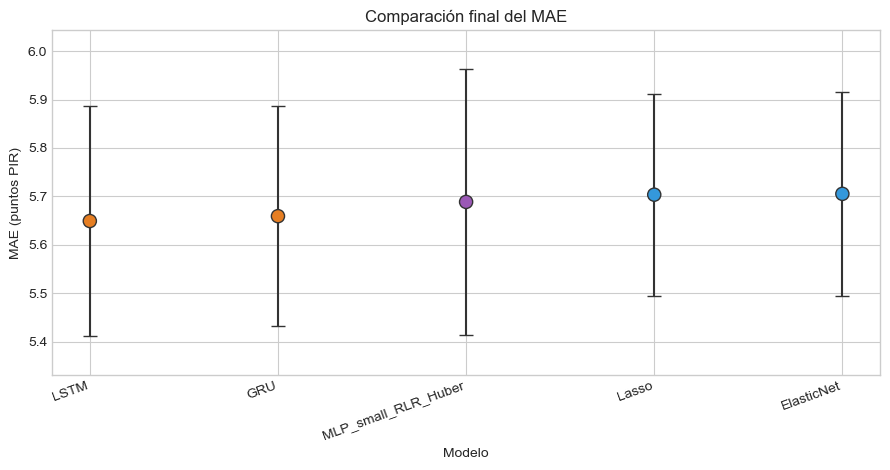

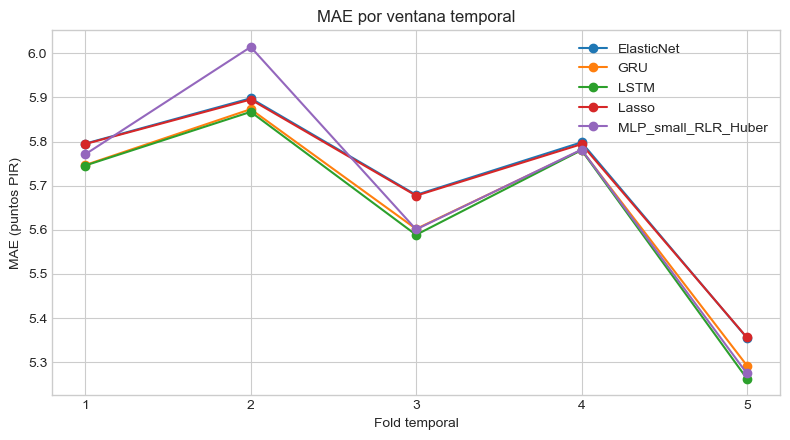

In [8]:
comparison.to_csv(TABLE_DIR / "figure_model_comparison_source.csv", index=False)
all_by_fold.to_csv(TABLE_DIR / "figure_mae_by_fold_source.csv", index=False)
history.query("seed == 42").to_csv(TABLE_DIR / "figure_training_curves_source.csv", index=False)


figure_history = history.query("seed == 42").copy()
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=False, sharey=True)
for row, model_name in enumerate(["LSTM", "GRU"]):
    for column, fold in enumerate(range(1, 6)):
        ax = axes[row, column]
        values = figure_history.query("model == @model_name and fold == @fold")
        ax.plot(values["epoch"], values["train_mae"], label="Entrenamiento")
        ax.plot(values["epoch"], values["validation_mae"], label="Validación")
        ax.set(title=f"Fold {fold}", xlabel="Epoch")
        if column == 0:
            ax.set_ylabel(f"{model_name}\nMAE")
axes[0, -1].legend()
fig.suptitle("Curvas de entrenamiento LSTM y GRU (semilla 42)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sequence_training_curves.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
positions = np.arange(len(comparison))
colors = ["#3498db" if model in {"Lasso", "ElasticNet"} else "#9b59b6" if model.startswith("MLP") else "#e67e22" for model in comparison["model"]]
ax.errorbar(positions, comparison["mae_mean"], yerr=comparison["mae_std"], fmt="none", ecolor="#333333", capsize=5, zorder=2)
ax.scatter(positions, comparison["mae_mean"], s=90, c=colors, edgecolor="#333333", zorder=3)
ax.set(title="Comparación final del MAE", xlabel="Modelo", ylabel="MAE (puntos PIR)")
ax.set_xticks(positions, comparison["model"], rotation=20, ha="right")
margin = 0.08
ax.set_ylim((comparison["mae_mean"] - comparison["mae_std"]).min() - margin, (comparison["mae_mean"] + comparison["mae_std"]).max() + margin)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sequence_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for model, values in all_by_fold.groupby("model"):
    ax.plot(values["fold"], values["mae"], marker="o", label=model)
ax.set(title="MAE por ventana temporal", xlabel="Fold temporal", ylabel="MAE (puntos PIR)", xticks=range(1, 6))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sequence_mae_by_fold.png", dpi=160, bbox_inches="tight")
plt.show()

## Conclusión

La conclusión numérica se obtiene de los CSV regenerados en esta ejecución. Debe distinguirse entre menor MAE, control de errores grandes mediante RMSE y variabilidad explicada mediante R²; no se declarará un ganador universal si esas métricas discrepan.

El alcance se limita a dos arquitecturas pequeñas y a una longitud máxima de diez partidos durante una temporada. En consecuencia, no puede generalizarse la superioridad de ML o DL fuera de este protocolo.

TensorBoard puede abrirse con `python -m tensorboard.main --logdir reports/tensorboard/05_sequence` después de activar el entorno Conda.